<a href="https://colab.research.google.com/github/Pranesh-M-2006/Mechine-learning/blob/main/Exp%202/Scenario_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
# Roll No: 23AIXXX   # <-- Replace with your roll number

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             confusion_matrix, roc_curve, auc,
                             classification_report)


In [9]:
df = pd.read_csv("/content/LICI - 10 minute data.csv")

df.head()
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3684 entries, 0 to 3683
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    3684 non-null   object 
 1   open    3684 non-null   float64
 2   high    3684 non-null   float64
 3   low     3684 non-null   float64
 4   close   3684 non-null   float64
 5   volume  3684 non-null   int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 172.8+ KB


In [11]:
df['Price_Movement'] = np.where(df['close'] > df['open'], 1, 0)

df[['open','close','Price_Movement']].head()

,open,close,Price_Movement
0,872.00,872.00,0
1,872.00,872.00,0
2,872.00,902.80,1
3,902.45,902.15,0
4,902.30,903.85,1


In [13]:
features = ['open', 'high', 'low', 'volume']
X = df[features]
y = df['Price_Movement']

In [14]:
X = X.fillna(X.median())


In [15]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)


In [17]:
model = LogisticRegression()
model.fit(X_train, y_train)


LogisticRegression()

In [18]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]


In [19]:
print("Accuracy:", accuracy_score(y_test, y_pred))


Accuracy: 0.6132971506105834


In [20]:
print("Precision:", precision_score(y_test, y_pred))


Precision: 1.0


In [21]:
print("Recall:", recall_score(y_test, y_pred))


Recall: 0.030612244897959183


In [22]:
print("F1 Score:", f1_score(y_test, y_pred))


F1 Score: 0.0594059405940594


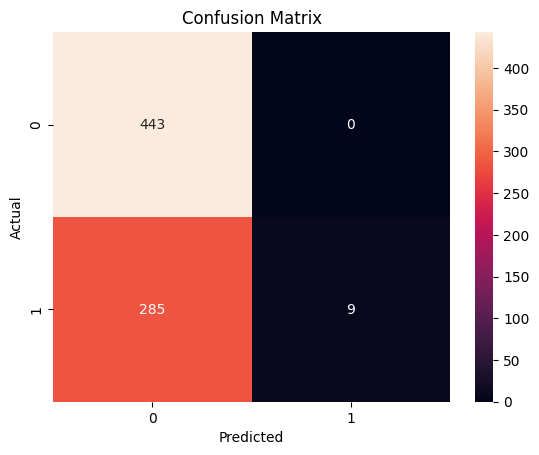

In [23]:
cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


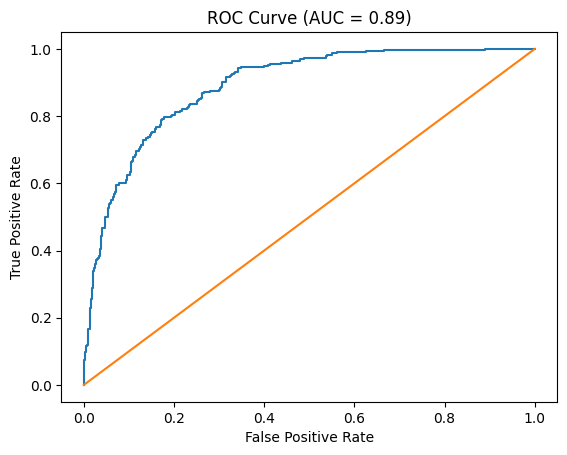

In [24]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (AUC = %0.2f)" % roc_auc)
plt.show()


In [25]:
importance = pd.DataFrame({
    'Feature': features,
    'Coefficient': model.coef_[0]
})

print(importance)


  Feature  Coefficient
0    open    -6.396031
1    high     4.100663
2     low     2.301069
3  volume    -0.019189


In [26]:
param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']
}

grid = GridSearchCV(LogisticRegression(), param_grid, cv=5)
grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  w

Best Parameters: {'C': 10, 'penalty': 'l1', 'solver': 'liblinear'}


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


In [27]:
best_model = grid.best_estimator_

y_pred_opt = best_model.predict(X_test)

print("Optimized Accuracy:", accuracy_score(y_test, y_pred_opt))


Optimized Accuracy: 0.8100407055630936
